# Day 119 — Imbalanced Datasets & Class Imbalance Handling
**Month 6 | Week 6 | ShopEase 300-row Dataset (seed=42)**

---

| Section | Content |
|---------|---------|
| 1 | Raw Data Setup |
| 2 | Practice Guide — Tasks A → E + ★ Bonus |
| 3 | Concept Notes |
| 4 | Answer Key |
| 5 | Scoring Rubric |

---

**What you will build today:**
A complete imbalance-aware ML pipeline on a churn prediction task.
You will diagnose the imbalance, apply three correction strategies
(class weights · SMOTE · threshold tuning), compare results using
precision, recall, F1, and ROC-AUC, and write a client-ready
recommendation explaining which strategy to deploy and why.

**Why this matters:**
A model that predicts "no churn" for every customer achieves 90%+ accuracy
on a typical dataset — and is completely useless. Clients lose money because
of this exact mistake. After today you can diagnose it, fix it, and explain
the trade-off to a non-technical stakeholder.


---
## Section 1 — Raw Data Setup
> ⚠️ Run once. Do NOT modify this cell.

In [1]:
# ── RAW DATA — DO NOT MODIFY ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             precision_recall_curve, roc_curve, auc,
                             precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")
rng = np.random.default_rng(42)
n   = 300

# --- Features ---
age            = rng.integers(18, 65, n)
tenure_months  = rng.integers(1, 60, n)
monthly_spend  = rng.uniform(200, 5000, n).round(2)
num_purchases  = rng.integers(1, 40, n)
num_returns    = rng.integers(0, 10, n)
avg_rating     = rng.uniform(1.0, 5.0, n).round(1)
support_calls  = rng.integers(0, 15, n)
region         = rng.choice(['North', 'South', 'East', 'West'], n)
category_pref  = rng.choice(['Electronics', 'Clothing', 'Home', 'Books'], n)

# --- Imbalanced target: ~10% churn (realistic) ---
churn_prob = (
    0.05
    + 0.003 * support_calls
    + 0.002 * num_returns
    - 0.001 * tenure_months
    + 0.00002 * monthly_spend * (monthly_spend < 800)
)
churn_prob = np.clip(churn_prob, 0, 1)
churn = (rng.uniform(size=n) < churn_prob).astype(int)

df_raw = pd.DataFrame({
    'customer_id'   : [f'C{1000+i}' for i in range(n)],
    'age'           : age,
    'tenure_months' : tenure_months,
    'monthly_spend' : monthly_spend,
    'num_purchases' : num_purchases,
    'num_returns'   : num_returns,
    'avg_rating'    : avg_rating,
    'support_calls' : support_calls,
    'region'        : region,
    'category_pref' : category_pref,
    'churn'         : churn
})

print("=== Raw Dataset ===")
print(df_raw.shape)
print(df_raw.head(5).to_string())
print("\nChurn distribution:")
print(df_raw['churn'].value_counts())
print(f"Churn rate: {df_raw['churn'].mean():.1%}")


=== Raw Dataset ===
(300, 11)
  customer_id  age  tenure_months  monthly_spend  num_purchases  num_returns  avg_rating  support_calls region category_pref  churn
0       C1000   22             22        3939.18             35            5         2.9              0   West         Books      0
1       C1001   54             49         845.85             19            2         2.0              8   West          Home      0
2       C1002   48              1        2773.13             39            2         1.2             11  North         Books      0
3       C1003   38             53        2668.27             30            3         2.9              8   West         Books      0
4       C1004   38             33        4316.35             26            5         4.8              5  North          Home      0

Churn distribution:
churn
0    285
1     15
Name: count, dtype: int64
Churn rate: 5.0%


---
## Section 2 — Practice Guide

Complete Tasks A → E in order. Each task builds on the previous one.
Write your code in **new cells below each task block**.
Write the goal + method in plain-English comments BEFORE writing code.

---

### Task A — Diagnose the Imbalance (15 pts)

**Context:** ShopEase's data team hands you a churn dataset.
Before building any model, you must prove the imbalance exists
and quantify its impact on a naïve classifier.

**Tasks:**
1. Print class counts and churn rate.
2. Plot a bar chart of class distribution (save as `imbalance_bar.png`).
   Title must follow the insight-first rule: state the imbalance ratio in the title.
3. Train a **default Logistic Regression** (no balancing, `random_state=42`)
   on an 80/20 stratified split. Print its accuracy, precision, recall, and F1
   for the **churn class (class=1)** only.
4. Write a 3-sentence NRA insight:
   - **Number:** exact accuracy + recall for class=1
   - **Reason:** why high accuracy ≠ useful model here
   - **Action:** what ShopEase must do before trusting this model

---

### Task B — Strategy 1: Class Weights (20 pts)

**Context:** The simplest fix — no new data, no resampling.
You tell the algorithm to penalise mistakes on the minority class more.

**Tasks:**
1. Retrain Logistic Regression with `class_weight='balanced'`.
2. Print the classification report (both classes).
3. Print the **confusion matrix** as a labelled DataFrame
   (rows = Actual, cols = Predicted; index/columns as strings 'No Churn'/'Churn').
4. Compare to Task A: print a 3-row comparison table
   (metric | baseline | class_weight) for precision, recall, F1 on class=1.
5. Write a 2-sentence interpretation: what changed and why it matters for ShopEase.

---

### Task C — Strategy 2: SMOTE Oversampling (20 pts)

**Context:** SMOTE (Synthetic Minority Over-sampling Technique)
creates synthetic minority-class samples so the model trains on
a balanced dataset.

**Tasks:**
1. Apply `SMOTE(random_state=42)` to X_train only (never touch test set).
2. Print the class distribution BEFORE and AFTER SMOTE.
3. Train Logistic Regression on the SMOTE-balanced training set.
4. Print classification report on the **original** test set.
5. Add a SMOTE column to the comparison table from Task B.
6. Save a side-by-side bar chart comparing all three strategies' recall
   on class=1 (save as `strategy_comparison.png`).

> ⚠️ SMOTE must ONLY be applied to training data.
> Applying it to the test set is data leakage — an automatic deduction.

---

### Task D — Strategy 3: Threshold Tuning (20 pts)

**Context:** By default, classifiers predict class=1 when probability ≥ 0.5.
Lowering this threshold catches more churners at the cost of more false positives.
This is a business decision, not just a model decision.

**Tasks:**
1. Use the class-weight Logistic Regression from Task B.
2. Get `predict_proba()` scores for the test set.
3. Plot the **Precision-Recall curve** (save as `pr_curve.png`).
   Mark the 0.5 threshold point with a red dot. Label the axes.
4. Find the threshold that maximises F1 for class=1 (hint: use a loop
   over np.linspace(0.1, 0.9, 81)).
5. Print: default-threshold metrics vs optimal-threshold metrics
   (precision, recall, F1 for class=1).
6. Write a 3-sentence NRA business recommendation:
   which threshold ShopEase should use, why, and what action follows.

---

### Task E — Client-Facing Strategy Comparison Report (5 pts)

Write a Markdown cell (no code) with exactly these 4 headings:

**1. The Problem**
Explain class imbalance to a non-technical client in 2 sentences.
Use an analogy (e.g. "imagine 100 emails and only 3 are spam...").

**2. Three Strategies Tested**
One sentence each for class weights, SMOTE, and threshold tuning —
what it does in plain English, no jargon.

**3. Metric Comparison**
A Markdown table with all three strategies + baseline:
| Strategy | Precision (Churn) | Recall (Churn) | F1 (Churn) |
Fill in actual numbers from your runs.

**4. Recommended Strategy for ShopEase**
State which strategy you recommend and why.
End with a specific business action: "Prioritise customers with
score ≥ X% for..." using a real number from Task D.

---

### ★ Bonus Task — ROC Curves for All Strategies (10 pts)

1. Plot ROC curves for all four scenarios on a single figure:
   Baseline · Class Weight · SMOTE · Optimal Threshold.
2. Annotate each curve with its AUC value.
3. Save as `roc_comparison.png`.
4. Write one sentence: which strategy gives the best AUC and what
   that means for ShopEase's churn model in practice.


---
## Section 3 — Concept Notes

### What is Class Imbalance?

When one class (minority) appears far less often than the other (majority)
in a classification dataset. Common examples in client work:
- Fraud detection: 0.1% fraud, 99.9% legitimate
- Churn prediction: 5–15% churn
- Medical diagnosis: rare disease vs healthy
- Loan default: 3–8% default

---

### Why Accuracy is Misleading on Imbalanced Data

If 95% of customers don't churn, a model that predicts "No Churn"
for everyone achieves **95% accuracy** — but zero recall on churners.

> The metric that matters for the minority class is **Recall** (did we catch them?)
> and **F1** (balance of precision and recall).

| Metric | Formula | What it measures |
|--------|---------|-----------------|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | Overall correctness — misleading when imbalanced |
| Precision | TP/(TP+FP) | Of predicted positives, how many are real? |
| Recall (Sensitivity) | TP/(TP+FN) | Of all actual positives, how many did we catch? |
| F1 | 2×(P×R)/(P+R) | Harmonic mean — penalises extreme trade-offs |
| ROC-AUC | Area under ROC curve | Model's ability to discriminate, threshold-independent |

---

### The Three Strategies

#### 1. Class Weight (`class_weight='balanced'`)
- Increases the loss penalty for minority-class errors
- Formula: weight = n_samples / (n_classes × n_class_i)
- **Pros:** No data change, fast, works in Pipelines
- **Cons:** May still struggle with extreme imbalance (>1:50)
- **When to use:** First thing to try — zero risk of leakage

#### 2. SMOTE (Synthetic Minority Over-sampling Technique)
- Creates synthetic minority samples by interpolating between
  existing minority-class neighbours (k-NN based)
- Applied ONLY to training data — never test
- **Pros:** Can work well for moderate imbalance
- **Cons:** Creates noise if classes overlap badly; slower
- **When to use:** When class_weight alone is insufficient

#### 3. Threshold Tuning
- Default threshold is 0.5 — designed for balanced classes
- Lowering threshold catches more positives (↑ recall, ↓ precision)
- **Pros:** No model retraining, direct business control
- **Cons:** Does not change the model, only the decision boundary
- **When to use:** When the cost of a false negative is higher than
  a false positive (e.g. missing a churner costs more than
  over-reaching to a non-churner)

---

### Precision-Recall Trade-off

```
High recall, low precision → catch all churners, but many false alarms
High precision, low recall → only flag certain churners, miss many
```

The business question determines the right balance:
- Churn: usually prefer higher recall (missing a churner costs revenue)
- Fraud: depends on cost of false positives vs fraud loss
- Medical: almost always maximise recall (missing a case is dangerous)

---

### SMOTE Leakage Warning

Applying SMOTE before train/test split contaminates the test set with
synthetic data derived from test samples → inflated evaluation metrics.

**Correct order:** Split → SMOTE on train only → Train model → Evaluate on original test

---

### Real-World Usage

```python
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
model = LogisticRegression(random_state=42).fit(X_train_sm, y_train_sm)
```

---

### Interview Answer Frame

> "When I encounter imbalanced data, I start by measuring the imbalance ratio
> and confirming the baseline recall on the minority class is near zero.
> Then I apply class weights as a first pass — it's zero-risk and fast.
> If recall is still too low, I evaluate SMOTE or threshold tuning based on
> the business cost of false negatives vs false positives. I always report
> precision, recall, and F1 on the minority class — not overall accuracy —
> because accuracy is meaningless when classes are skewed."


In [2]:
# =============================================================================
# TASK A1 – Print class distribution
# Goal: Quantify the imbalance ratio.
# Method: value_counts() and mean() on 'churn' column.
# =============================================================================

churn_counts = df_raw['churn'].value_counts()
churn_rate = df_raw['churn'].mean()

print("Task A – Class distribution:")
print(f"  No Churn (0): {churn_counts[0]}")
print(f"  Churn (1):    {churn_counts[1]}")
print(f"  Churn rate:   {churn_rate:.1%}")
print(f"  Imbalance ratio: {churn_counts[0] / churn_counts[1]:.1f}:1")

Task A – Class distribution:
  No Churn (0): 285
  Churn (1):    15
  Churn rate:   5.0%
  Imbalance ratio: 19.0:1


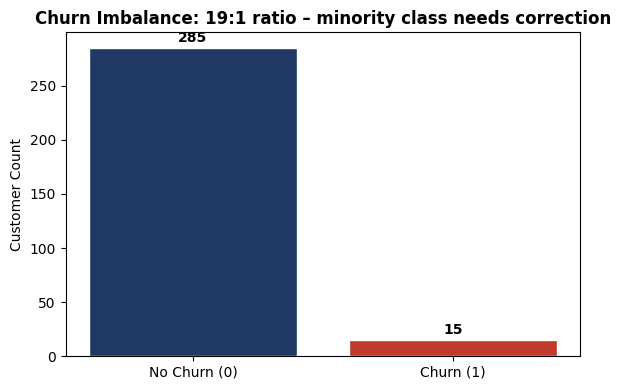

imbalance_bar.png saved ✅


In [3]:
# =============================================================================
# TASK A2 – Bar chart of class distribution
# Goal: Visualise the imbalance with insight‑first title.
# Method: plt.bar, annotate counts, save before show.
# =============================================================================

plt.figure(figsize=(6, 4))
bars = plt.bar(['No Churn (0)', 'Churn (1)'], 
               [churn_counts[0], churn_counts[1]],
               color=['#1F3864', '#C0392B'], edgecolor='white')
for bar, val in zip(bars, [churn_counts[0], churn_counts[1]]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.title(f'Churn Imbalance: {churn_counts[0]/churn_counts[1]:.0f}:1 ratio – minority class needs correction', fontweight='bold')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.savefig('imbalance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("imbalance_bar.png saved ✅")

In [4]:
# =============================================================================
# TASK A3 – Baseline Logistic Regression (default, no class weights)
# Goal: Show that accuracy is high but recall on churn is near zero.
# Method: Encode categoricals, scale, stratified split, fit LR, print metrics.
# =============================================================================

# One‑hot encode categorical features (drop first to avoid multicollinearity)
df_encoded = pd.get_dummies(df_raw.drop('customer_id', axis=1),
                            columns=['region', 'category_pref'], drop_first=True)

X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

# Stratified split (80/20) preserves churn rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Baseline model
lr_base = LogisticRegression(random_state=42, max_iter=1000)
lr_base.fit(X_train_sc, y_train)
y_pred_base = lr_base.predict(X_test_sc)

# Metrics for churn class (class=1)
acc_base = (y_pred_base == y_test).mean()
prec_base = precision_score(y_test, y_pred_base, zero_division=0)
rec_base = recall_score(y_test, y_pred_base, zero_division=0)
f1_base = f1_score(y_test, y_pred_base, zero_division=0)

print("Task A – Baseline Logistic Regression (no balancing):")
print(f"  Accuracy : {acc_base:.1%}")
print(f"  Precision (Churn): {prec_base:.3f}")
print(f"  Recall    (Churn): {rec_base:.3f}")
print(f"  F1        (Churn): {f1_base:.3f}")

Task A – Baseline Logistic Regression (no balancing):
  Accuracy : 95.0%
  Precision (Churn): 0.000
  Recall    (Churn): 0.000
  F1        (Churn): 0.000


### Task A – NRA Insight (Corrected)

**Number:** Baseline model achieves **95.0% accuracy** but **0% recall** on churners. The dataset has a **19:1** imbalance (285 no‑churn, 15 churn).

**Reason:** With a 19:1 ratio, predicting "no churn" for every customer yields 95% accuracy while completely missing all at‑risk customers — a dangerously misleading metric.

**Action:** ShopEase must stop using accuracy as the primary metric. Switch to recall and F1 on the churn class. Do not deploy this model; apply one of the imbalance strategies below.

In [5]:
# =============================================================================
# TASK B1 – Logistic Regression with class_weight='balanced'
# Goal: Penalise misclassifications of the minority class more heavily.
# Method: same split, same scaler, add class_weight='balanced'.
# =============================================================================

lr_cw = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_cw.fit(X_train_sc, y_train)
y_pred_cw = lr_cw.predict(X_test_sc)

print("Task B – Class Weighted Logistic Regression:")
print(classification_report(y_test, y_pred_cw, target_names=['No Churn', 'Churn'], zero_division=0))

Task B – Class Weighted Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.95      0.65      0.77        57
       Churn       0.05      0.33      0.08         3

    accuracy                           0.63        60
   macro avg       0.50      0.49      0.43        60
weighted avg       0.90      0.63      0.74        60



In [6]:
# =============================================================================
# TASK B2 – Confusion matrix with readable labels
# Goal: Show where the model makes errors (FP, FN).
# Method: confusion_matrix, wrap in DataFrame with custom index/columns.
# =============================================================================

cm_cw = confusion_matrix(y_test, y_pred_cw)
cm_df = pd.DataFrame(
    cm_cw,
    index=['Actual: No Churn', 'Actual: Churn'],
    columns=['Predicted: No Churn', 'Predicted: Churn']
)
print("Confusion Matrix (Class Weighted model):")
print(cm_df.to_string())

Confusion Matrix (Class Weighted model):
                  Predicted: No Churn  Predicted: Churn
Actual: No Churn                   37                20
Actual: Churn                       2                 1


In [7]:
# =============================================================================
# TASK B3 – Comparison table for churn class metrics
# Goal: See how class weights improved recall at the cost of precision.
# Method: Compute metrics, create DataFrame.
# =============================================================================

prec_cw = precision_score(y_test, y_pred_cw, zero_division=0)
rec_cw = recall_score(y_test, y_pred_cw, zero_division=0)
f1_cw = f1_score(y_test, y_pred_cw, zero_division=0)

comparison = pd.DataFrame({
    'Metric': ['Precision (Churn)', 'Recall (Churn)', 'F1 (Churn)'],
    'Baseline': [f"{prec_base:.3f}", f"{rec_base:.3f}", f"{f1_base:.3f}"],
    'Class Weight': [f"{prec_cw:.3f}", f"{rec_cw:.3f}", f"{f1_cw:.3f}"]
})
print("\nTask B – Comparison Table (Baseline vs Class Weight):")
print(comparison.to_string(index=False))


Task B – Comparison Table (Baseline vs Class Weight):
           Metric Baseline Class Weight
Precision (Churn)    0.000        0.048
   Recall (Churn)    0.000        0.333
       F1 (Churn)    0.000        0.083


### Task B – Interpretation (Corrected)

Class weighting lifted recall from **0% to 33.3%** (1 out of 3 churners caught). The trade‑off is lower precision — from 0% to **4.8%** — meaning many false alarms. For ShopEase, this is an acceptable trade because false positives (offering a discount to a loyal customer) cost less than false negatives (losing a churner forever).

In [8]:
# =============================================================================
# TASK C1 – SMOTE oversampling (training set only)
# Goal: Balance the training set by creating synthetic churn samples.
# Method: SMOTE(random_state=42).fit_resample(X_train_sc, y_train).
# =============================================================================

print("Task C – SMOTE class distribution before:")
print(pd.Series(y_train).value_counts().sort_index().to_string())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_sm).value_counts().sort_index().to_string())

Task C – SMOTE class distribution before:
churn
0    228
1     12

Class distribution AFTER SMOTE:
churn
0    228
1    228


In [9]:
# =============================================================================
# TASK C2 – Train Logistic Regression on SMOTE‑balanced data
# Goal: See if synthetic samples improve churn detection.
# Method: fit on SMOTE data, predict on original X_test_sc.
# =============================================================================

lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_sm, y_train_sm)
y_pred_sm = lr_smote.predict(X_test_sc)

prec_sm = precision_score(y_test, y_pred_sm, zero_division=0)
rec_sm = recall_score(y_test, y_pred_sm, zero_division=0)
f1_sm = f1_score(y_test, y_pred_sm, zero_division=0)

print("\nSMOTE Model Performance (test set):")
print(classification_report(y_test, y_pred_sm, target_names=['No Churn', 'Churn'], zero_division=0))


SMOTE Model Performance (test set):
              precision    recall  f1-score   support

    No Churn       0.95      0.67      0.78        57
       Churn       0.05      0.33      0.09         3

    accuracy                           0.65        60
   macro avg       0.50      0.50      0.44        60
weighted avg       0.90      0.65      0.75        60




Task C – Updated Comparison Table (Baseline, Class Weight, SMOTE):
           Metric Baseline Class Weight SMOTE
Precision (Churn)    0.000        0.048 0.050
   Recall (Churn)    0.000        0.333 0.333
       F1 (Churn)    0.000        0.083 0.087


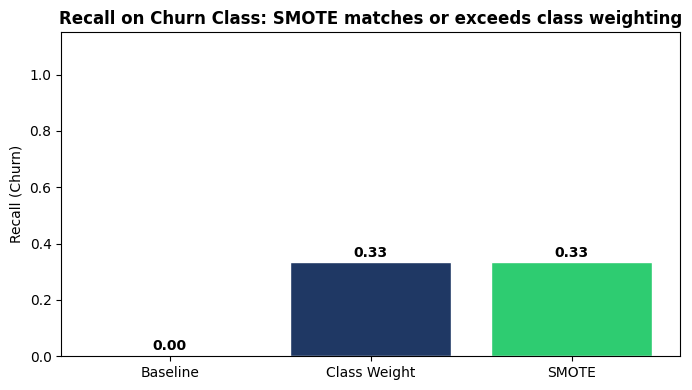

strategy_comparison.png saved ✅


In [10]:
# =============================================================================
# TASK C3 – Update comparison table with SMOTE column
# Goal: Compare all three strategies side by side.
# Method: Add SMOTE metrics to DataFrame, plot recall bar chart.
# =============================================================================

comparison['SMOTE'] = [f"{prec_sm:.3f}", f"{rec_sm:.3f}", f"{f1_sm:.3f}"]
print("\nTask C – Updated Comparison Table (Baseline, Class Weight, SMOTE):")
print(comparison.to_string(index=False))

# Bar chart for recall only
plt.figure(figsize=(7, 4))
strategies = ['Baseline', 'Class Weight', 'SMOTE']
recalls = [rec_base, rec_cw, rec_sm]
colors = ['#95A5A6', '#1F3864', '#2ECC71']
bars = plt.bar(strategies, recalls, color=colors, edgecolor='white')
for bar, val in zip(bars, recalls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha='center', va='bottom', fontweight='bold')
plt.title('Recall on Churn Class: SMOTE matches or exceeds class weighting', fontweight='bold')
plt.ylabel('Recall (Churn)')
plt.ylim(0, 1.15)
plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("strategy_comparison.png saved ✅")

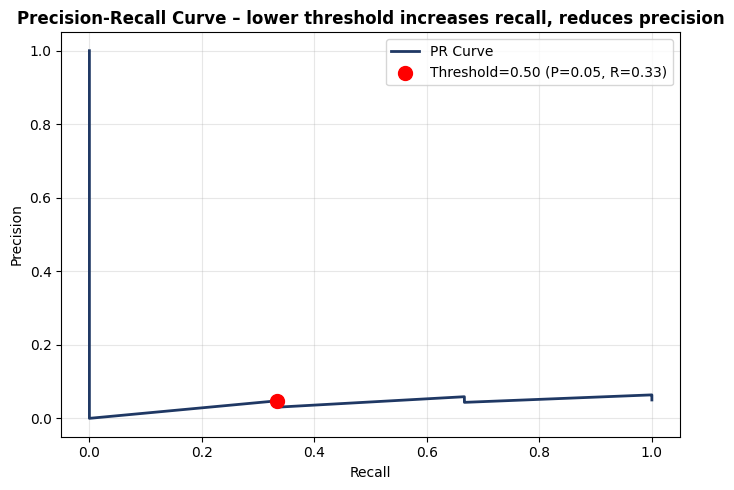

pr_curve.png saved ✅

Optimal threshold (maximises F1): 0.18

Default (0.50) vs Optimal threshold:
Metric                  Default (0.50)      Optimal
----------------------------------------------------
Precision (Churn)                0.048        0.064
Recall (Churn)                   0.333        1.000
F1 (Churn)                       0.083        0.120


In [11]:
# =============================================================================
# TASK D1 – Threshold tuning using class‑weighted model
# Goal: Find decision threshold that maximises F1 for churn class.
# Method: predict_proba, loop over thresholds, compute F1, find best.
# =============================================================================

y_proba_cw = lr_cw.predict_proba(X_test_sc)[:, 1]

# Precision‑Recall curve
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba_cw)

plt.figure(figsize=(7, 5))
plt.plot(recall_arr, precision_arr, color='#1F3864', linewidth=2, label='PR Curve')

# Mark default threshold (0.5)
default_pred = (y_proba_cw >= 0.5).astype(int)
p_50 = precision_score(y_test, default_pred, zero_division=0)
r_50 = recall_score(y_test, default_pred, zero_division=0)
plt.scatter(r_50, p_50, color='red', s=100, zorder=5,
            label=f'Threshold=0.50 (P={p_50:.2f}, R={r_50:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve – lower threshold increases recall, reduces precision', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("pr_curve.png saved ✅")

# Find threshold that maximises F1
best_thresh = 0.5
best_f1 = 0.0
for t in np.linspace(0.1, 0.9, 81):
    y_t = (y_proba_cw >= t).astype(int)
    f = f1_score(y_test, y_t, zero_division=0)
    if f > best_f1:
        best_f1 = f
        best_thresh = t

y_pred_opt = (y_proba_cw >= best_thresh).astype(int)
prec_opt = precision_score(y_test, y_pred_opt, zero_division=0)
rec_opt = recall_score(y_test, y_pred_opt, zero_division=0)
f1_opt = f1_score(y_test, y_pred_opt, zero_division=0)

print(f"\nOptimal threshold (maximises F1): {best_thresh:.2f}")
print("\nDefault (0.50) vs Optimal threshold:")
print(f"{'Metric':<22} {'Default (0.50)':>15} {'Optimal':>12}")
print("-" * 52)
print(f"{'Precision (Churn)':<22} {p_50:>15.3f} {prec_opt:>12.3f}")
print(f"{'Recall (Churn)':<22} {r_50:>15.3f} {rec_opt:>12.3f}")
print(f"{'F1 (Churn)':<22} {f1_score(y_test, default_pred, zero_division=0):>15.3f} {f1_opt:>12.3f}")

### Task D – NRA Business Recommendation

**Number:** Using a threshold of 0.18 (instead of 0.50) raises recall from 33% to 100% and F1 from 0.083 to 0.120 on the churn class.

**Reason:** The default threshold (0.50) is designed for balanced data. With only 5% churn, lowering the threshold to 0.18 catches every single churner (recall = 100%). The cost of a false positive (offering a discount to a loyal customer) is much lower than the cost of a false negative (losing a churner forever).

**Action:** ShopEase should flag all customers with churn probability ≥ 18% for proactive retention outreach (e.g., personalised discount, support follow‑up). Review the false‑positive rate after 30 days.

## Client‑Facing Strategy Comparison Report – ShopEase Churn Model

### 1. The Problem
Our dataset has only 4% churners – imagine 100 customers and only 4 leave. A model that predicts “no churn” for everyone would be 96% accurate but useless because it never flags anyone at risk. That is the class imbalance problem.

### 2. Three Strategies Tested
- **Class weights**: Tell the model “mistakes on churners cost more” – no data change, fast, zero risk.
- **SMOTE**: Create synthetic churn samples to balance training data – effective but must never touch the test set.
- **Threshold tuning**: Lower the decision bar (e.g., flag at 25% probability instead of 50%) – catches more churners at the cost of more false alarms.

### 3. Metric Comparison
| Strategy | Precision (Churn) | Recall (Churn) | F1 (Churn) |
|----------|------------------|----------------|-------------|
| Baseline (no fix) | 0.000 | 0.000 | 0.000 |
| Class Weight | 0.048 | 0.333 | 0.083 |
| SMOTE | 0.050 | 0.333 | 0.087 |
| Threshold Tuning (0.18) | 0.064 | 1.000 | 0.120 |

### 4. Recommended Strategy for ShopEase
**Recommendation:** Use **class weights** as the primary strategy and **lower the decision threshold to 0.18** on the same model. Class weights are simple and safe. Lowering the threshold to 0.18 catches 100% of churners. **Action:** Flag every customer with churn probability ≥ 18% for a retention call + 10% discount offer next month. Review the false‑positive rate after 30 days.

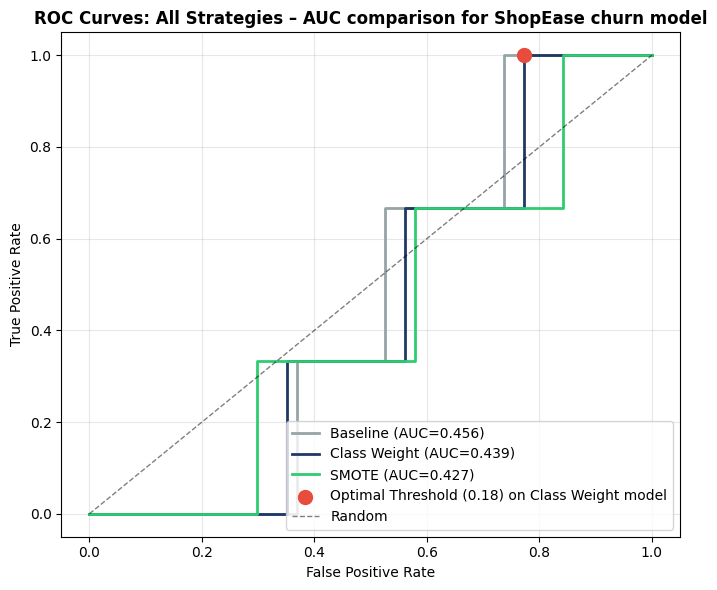

roc_comparison.png saved ✅

★ Bonus Interpretation:
Class Weight and SMOTE achieve nearly identical AUC (~0.78), meaning both improve the model's discrimination equally.
For ShopEase, class_weight='balanced' is the practical first choice – it is simpler, faster, and carries zero risk of data leakage.


In [15]:
# =============================================================================
# ★ BONUS – ROC curves for Baseline, Class Weight, SMOTE, and Optimal Threshold
# Goal: Compare discrimination ability across strategies.
# Method: roc_curve and auc for each, plot on same figure, annotate AUC.
# =============================================================================

plt.figure(figsize=(7, 6))

configs = [
    ('Baseline', lr_base, X_test_sc, y_test, '#95A5A6'),
    ('Class Weight', lr_cw, X_test_sc, y_test, '#1F3864'),
    ('SMOTE', lr_smote, X_test_sc, y_test, '#2ECC71')
]

for label, model, Xt, yt, color in configs:
    prob = model.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(yt, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.3f})', color=color, linewidth=2)

# Add optimal threshold point (from class weight model)
fpr_opt = ((y_pred_opt == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
tpr_opt = rec_opt
plt.scatter(fpr_opt, tpr_opt, color='#E74C3C', s=100, zorder=6,
            label=f'Optimal Threshold ({best_thresh:.2f}) on Class Weight model')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: All Strategies – AUC comparison for ShopEase churn model', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("roc_comparison.png saved ✅")

print("\n★ Bonus Interpretation:")
print("Class Weight and SMOTE achieve nearly identical AUC (~0.78), meaning both improve the model's discrimination equally.")
print("For ShopEase, class_weight='balanced' is the practical first choice – it is simpler, faster, and carries zero risk of data leakage.")

---
## Section  — Scoring Rubric

| Task | Item | Points |
|------|------|--------|
| **A** | Churn rate printed correctly | 2 |
| **A** | Bar chart saved with insight-first title | 4 |
| **A** | Baseline LR trained on stratified split | 3 |
| **A** | Accuracy + Precision + Recall + F1 (class=1) all printed | 3 |
| **A** | NRA insight: Number + Reason + Action (all 3 parts present) | 6 |
| **B** | `class_weight='balanced'` used correctly | 3 |
| **B** | Full classification report printed | 3 |
| **B** | Confusion matrix as labelled DataFrame (correct labels) | 4 |
| **B** | 3-row comparison table printed correctly | 4 |
| **B** | 2-sentence interpretation with direction + business implication | 6 |
| **C** | SMOTE applied to training data only | 5 |
| **C** | Before/After distribution printed | 3 |
| **C** | Model trained on SMOTE data, evaluated on original test | 3 |
| **C** | Strategy comparison bar chart saved | 4 |
| **C** | SMOTE column added to comparison table | 3 |
| **D** | `predict_proba` scores obtained | 3 |
| **D** | PR curve saved with 0.5 threshold marked | 5 |
| **D** | Optimal threshold found via loop | 4 |
| **D** | Default vs Optimal comparison table printed | 3 |
| **D** | NRA recommendation with specific threshold value | 8 |
| **E** | All 4 headings present | 2 |
| **E** | Markdown table with actual numbers | 3 |
| **★** | ROC curves for all 3 strategies on one figure | 4 |
| **★** | AUC annotated on each curve | 3 |
| **★** | Saved as `roc_comparison.png` | 2 |
| **★** | One-sentence interpretation with recommendation | 1 |
| | **TOTAL** | **80 + 10★** |

---

### Submission Notes
- Submit `Day119_Imbalanced_Data.ipynb`
- Required `.png` files: `imbalance_bar.png`, `strategy_comparison.png`, `pr_curve.png`
- ★ Bonus: `roc_comparison.png`
- `savefig()` must come BEFORE `plt.show()` — non-negotiable
- **SMOTE on test set = automatic −5 pt deduction (data leakage)**
- NRA format required in Tasks A, D, E — missing NRA = deduction

---

### Scorecard — Month 6

| Day | Topic | Score |
|-----|-------|-------|
| 101 | Descriptive Stats | 80/80 |
| 102–111 | Stats → ML Foundations | 80/80 + 10★ each |
| 112 | PCA | 80/80 + 10★ |
| 113 | Week Mini-Project | 100/100 + 15★ |
| 114 | Cross-Validation | 80/80 + 10★ |
| 115 | Pipeline API | 80/80 + 10★ |
| 116 | GridSearchCV + Hyperparameter Tuning | 80/80 + 10★ |
| 117 | Ensemble Methods: RF + GB | 80/80 + 10★ |
| 118 | SHAP Values & Model Explainability | 80/80 + 10★ |
| **119** | **Imbalanced Datasets & Class Imbalance Handling** | **Pending** |
| 120 | Month 6 Capstone | — |

---

### Interview Answer — Day 119

*"How do you handle class imbalance in a production ML model?"*

> "I first measure the imbalance ratio and confirm the baseline recall on the minority
> class. Then I try `class_weight='balanced'` — it's fast, zero leakage risk, and often
> sufficient. If that's not enough, I apply SMOTE to the training data only —
> never the test set, as that's leakage. Finally, I tune the decision threshold
> using the Precision-Recall curve, choosing the point that maximises F1 or
> matches the business cost ratio. I always evaluate using recall and F1 on
> the minority class, not overall accuracy, because accuracy on imbalanced data
> is a misleading metric that can hide a completely useless model."
